In [1]:
from nilearn import datasets, plotting
import nibabel as nib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from nilearn.datasets import fetch_atlas_schaefer_2018
from upsetplot import UpSet, from_indicators
from nilearn.image import load_img
from venn import venn
from matplotlib.colors import LinearSegmentedColormap

These next few cells are to visualize the atlas, they're not needed for the whole notebook.

In [2]:
atlas_path = "Schaefer2018_200Parcels_7Networks_order_FSLMNI152_1mm.nii.gz"

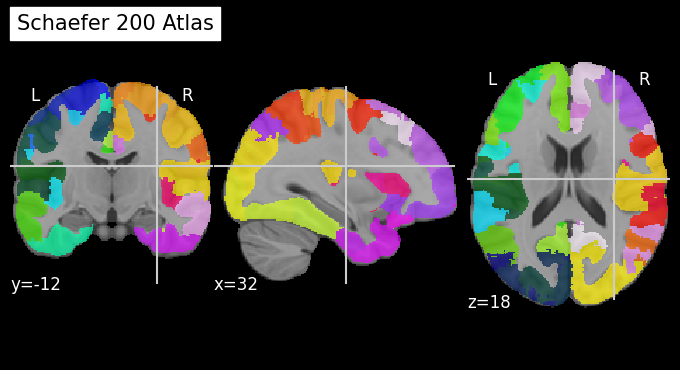

In [3]:
# Load Schaefer atlas in MNI152 space
mni152 = datasets.load_mni152_template()
plotting.plot_roi(atlas_path, bg_img=mni152, title="Schaefer 200 Atlas")
plotting.show()

Load the data

In [4]:
connectome_data = pd.read_csv("../../Dataset/widsdatathon2025/TRAIN_NEW/TRAIN_FUNCTIONAL_CONNECTOME_MATRICES_new_36P_Pearson.csv")

In [5]:
train_labels = pd.read_excel("../../Dataset/widsdatathon2025/TRAIN_NEW/TRAINING_SOLUTIONS.xlsx")

In [6]:
# split the data into 4 splits
train_labels_adhd_male = train_labels[(train_labels["ADHD_Outcome"] == 1) & (train_labels["Sex_F"] == 0)] 
train_labels_adhd_female = train_labels[(train_labels["ADHD_Outcome"] == 1) & (train_labels["Sex_F"] == 1)] 
train_labels_no_adhd_male = train_labels[(train_labels["ADHD_Outcome"] == 0) & (train_labels["Sex_F"] == 0)] 
train_labels_no_adhd_female = train_labels[(train_labels["ADHD_Outcome"] == 0) & (train_labels["Sex_F"] == 1)] 

In [7]:
connectome_data_adhd_male = connectome_data[connectome_data['participant_id'].isin(train_labels_adhd_male['participant_id'])]
connectome_data_adhd_female = connectome_data[connectome_data['participant_id'].isin(train_labels_adhd_female['participant_id'])]
connectome_data_no_adhd_male = connectome_data[connectome_data['participant_id'].isin(train_labels_no_adhd_male['participant_id'])]
connectome_data_no_adhd_female = connectome_data[connectome_data['participant_id'].isin(train_labels_no_adhd_female['participant_id'])]

In [8]:
expected_num_regions = 200

Build Adjacency matrices for 4 classes - ADHD (male), ADHD (female), No ADHD (male), No ADHD (female)

In [9]:
def construct_adjacency_matrix(connectome_data):
    connectivity_vectors = connectome_data.iloc[:, 1:].values
    num_patients = connectome_data.shape[0]

    upper_tri_indices = np.triu_indices(expected_num_regions, k=1)

    matrix_full = np.zeros((num_patients, expected_num_regions, expected_num_regions))

    for i in range(num_patients):
        matrix = np.zeros((expected_num_regions, expected_num_regions))
        matrix[upper_tri_indices] = connectivity_vectors[i]  
        matrix += matrix.T 
        np.fill_diagonal(matrix, 0)  
        matrix_full[i] = matrix

    return matrix_full  

In [10]:
matrix_adhd_male = construct_adjacency_matrix(connectome_data_adhd_male)
matrix_adhd_female = construct_adjacency_matrix(connectome_data_adhd_female)
matrix_no_adhd_male = construct_adjacency_matrix(connectome_data_no_adhd_male)
matrix_no_adhd_female = construct_adjacency_matrix(connectome_data_no_adhd_female)

In [11]:
print(matrix_adhd_male.shape)
print(matrix_adhd_female.shape)
print(matrix_no_adhd_male.shape)
print(matrix_no_adhd_female.shape)

(581, 200, 200)
(250, 200, 200)
(216, 200, 200)
(166, 200, 200)


<Axes: >

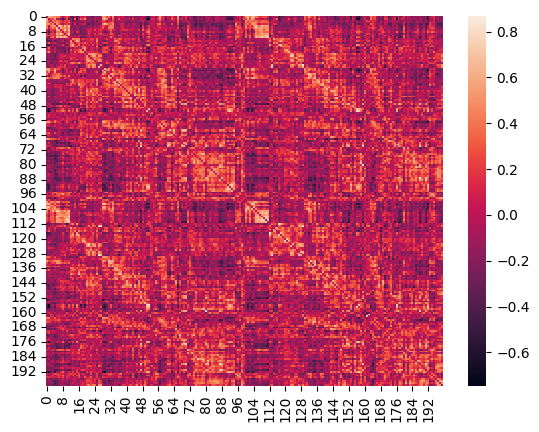

In [12]:
sns.heatmap(matrix_adhd_female[0])

In [13]:
mean_matrix_adhd_female = np.mean(matrix_adhd_female, axis=0)
mean_matrix_adhd_male = np.mean(matrix_adhd_male, axis=0)
mean_matrix_no_adhd_female = np.mean(matrix_no_adhd_female, axis=0)
mean_matrix_no_adhd_male = np.mean(matrix_no_adhd_male, axis=0)

In [14]:
mean_matrix_adhd_female.shape

(200, 200)

<Axes: >

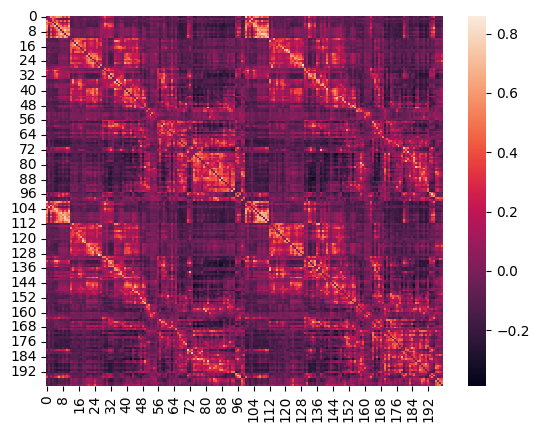

In [15]:
sns.heatmap(mean_matrix_adhd_female)

Plot the connectome based on "schaefer_2018" atlas with 200 regions, 7 netoworks and 1mm resolution. (This is the closest assumption I could get to). 10 nodes are plotted for visualization.

[get_dataset_dir] Dataset found in /Users/saadbinashraf/nilearn_data/schaefer_2018


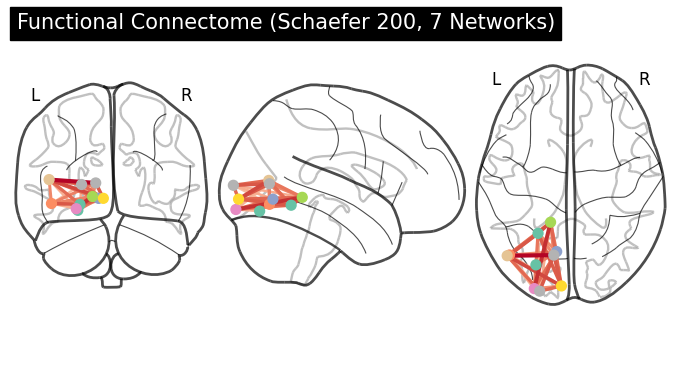

In [16]:
# Load Schaefer 2018 Atlas (200 parcels, 7 networks, 1mm MNI152)
atlas = fetch_atlas_schaefer_2018(n_rois=200, yeo_networks=7, resolution_mm=1)

# Extract MNI152 coordinates for 200 regions
atlas_img = load_img(atlas.maps)  # Load the atlas image

# Use nilearn's built-in function to find centroids for each parcel
atlas_coords = plotting.find_parcellation_cut_coords(atlas_img)

# Plot the connectome
plotting.plot_connectome(
    mean_matrix_adhd_female[:10, :10],
    atlas_coords[:10],
    edge_threshold=0.2,
    node_size=50,
    edge_cmap="coolwarm",
    title="Functional Connectome (Schaefer 200, 7 Networks)"
)

plotting.show()

According to the atlas - first 100 regions denote the left hemisphere of the brain while the next denote the right. This can be useful in analyzing inter-hemisphere connectivity - anything below index 100 is left, above 100 is right.

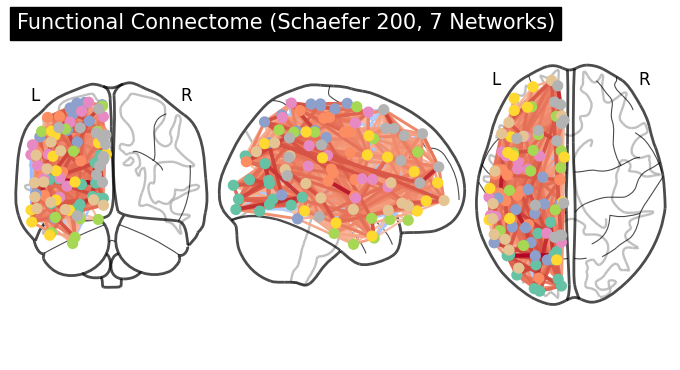

In [17]:
# Plot the connectome
plotting.plot_connectome(
    mean_matrix_adhd_female[:100, :100],
    atlas_coords[:100],
    edge_threshold=0.2,
    node_size=50,
    edge_cmap="coolwarm",
    title="Functional Connectome (Schaefer 200, 7 Networks)"
)

plotting.show()

Plotting connections based on a threshold

In [18]:
def get_valid_nodes_based_on_threshold(input_matrix, threshold):

    # Find out the valid nodes, reduce the adjacency matrix and get the coordinates
    output_matrix = input_matrix.copy()

    output_matrix[output_matrix < threshold] = 0  # Mask values below the threshold

    # Find the indices of the nodes that have any connection greater than the threshold
    valid_nodes = np.any(output_matrix > 0, axis=0)

    # Mask the atlas coordinates and the connectivity matrix
    masked_coords = np.array(atlas_coords)[valid_nodes]
    masked_matrix = input_matrix[valid_nodes][:, valid_nodes]

    return masked_matrix, masked_coords

In [19]:
adhd_female_significant_connections, adhd_female_coords = get_valid_nodes_based_on_threshold(mean_matrix_adhd_female, 0.7)

In [20]:
adhd_male_significant_connections, adhd_male_coords = get_valid_nodes_based_on_threshold(mean_matrix_adhd_male, 0.7)

In [21]:
no_adhd_female_significant_connections, no_adhd_female_coords = get_valid_nodes_based_on_threshold(mean_matrix_no_adhd_female, 0.7)

In [22]:
no_adhd_male_significant_connections, no_adhd_male_coords = get_valid_nodes_based_on_threshold(mean_matrix_no_adhd_male, 0.7)

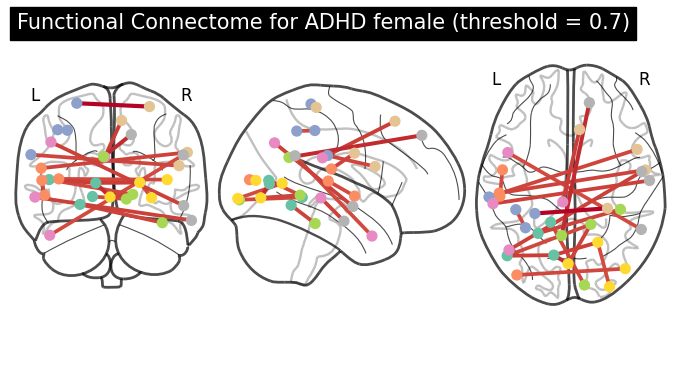

In [23]:
plotting.plot_connectome(
    adhd_female_significant_connections,
    adhd_female_coords,
    edge_threshold=0.7,
    node_size=50,
    edge_cmap="coolwarm",
    title="Functional Connectome for ADHD female (threshold = 0.7)"
)

# Show the plot
plotting.show()

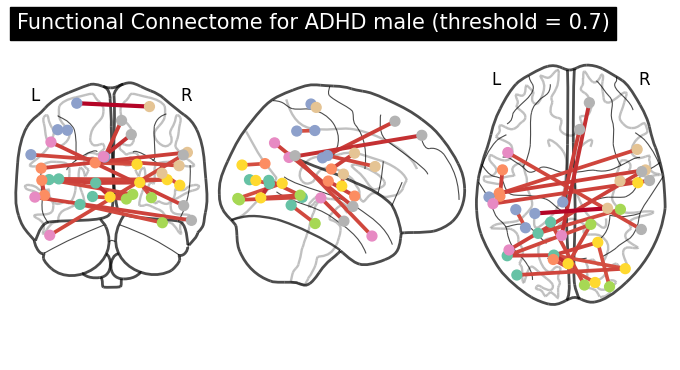

In [24]:
plotting.plot_connectome(
    adhd_male_significant_connections,
    adhd_male_coords,
    edge_threshold=0.7,
    node_size=50,
    edge_cmap="coolwarm",
    title="Functional Connectome for ADHD male (threshold = 0.7)"
)

# Show the plot
plotting.show()

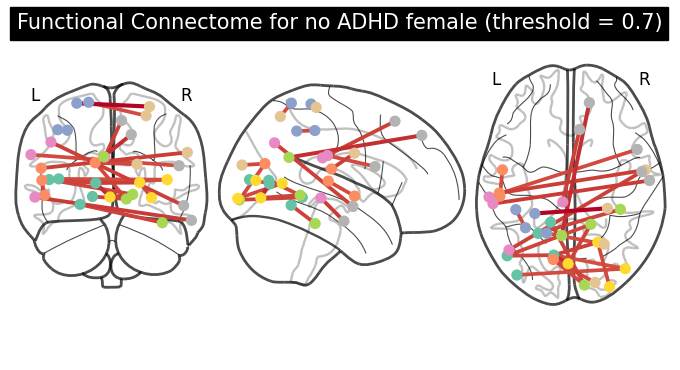

In [25]:
plotting.plot_connectome(
    no_adhd_female_significant_connections,
    no_adhd_female_coords,
    edge_threshold=0.7,
    node_size=50,
    edge_cmap="coolwarm",
    title="Functional Connectome for no ADHD female (threshold = 0.7)"
)

# Show the plot
plotting.show()

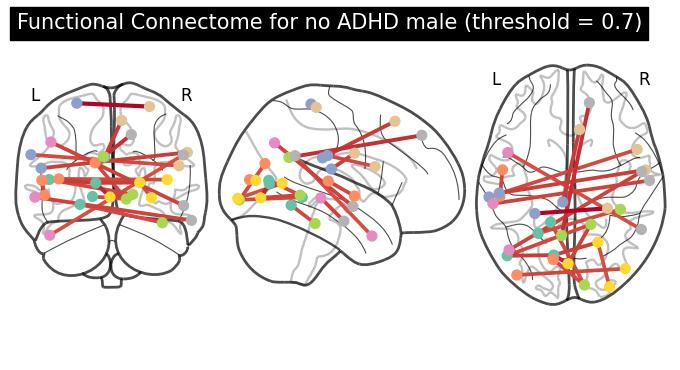

In [26]:
plotting.plot_connectome(
    no_adhd_male_significant_connections,
    no_adhd_male_coords,
    edge_threshold=0.7,
    node_size=50,
    edge_cmap="coolwarm",
    title="Functional Connectome for no ADHD male (threshold = 0.7)"
)

# Show the plot
plotting.show()

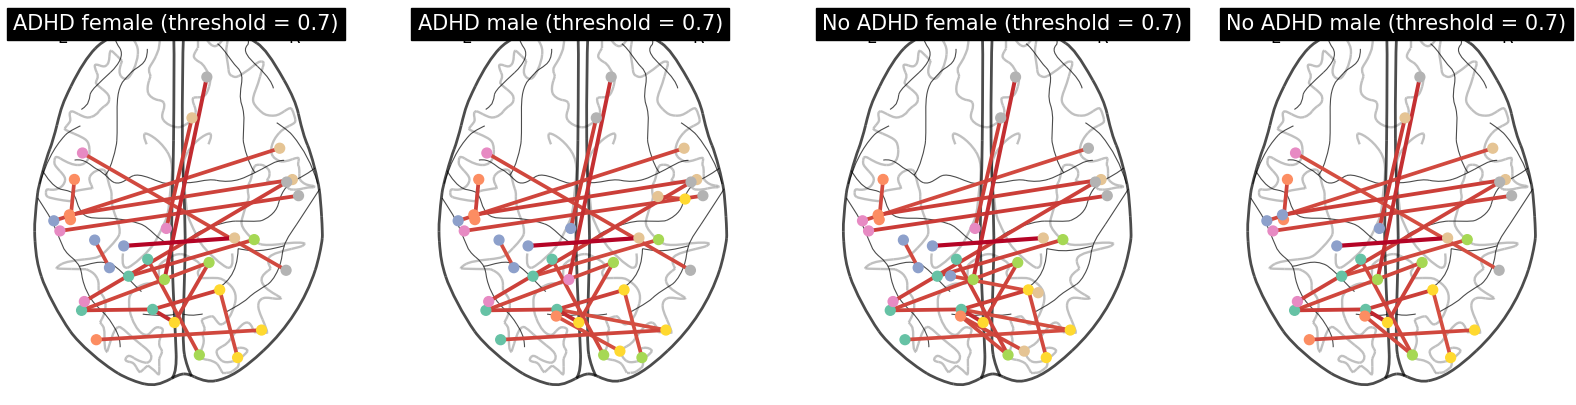

In [27]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))  # 1 row, 4 columns

plotting.plot_connectome(
    adhd_female_significant_connections,
    adhd_female_coords,
    edge_threshold=0.7,
    node_size=50,
    edge_cmap="coolwarm",
    title="ADHD female (threshold = 0.7)",
    axes=axes[0],
    display_mode="z"
)

plotting.plot_connectome(
    adhd_male_significant_connections,
    adhd_male_coords,
    edge_threshold=0.7,
    node_size=50,
    edge_cmap="coolwarm",
    title="ADHD male (threshold = 0.7)",
    axes=axes[1],
    display_mode="z"
)

plotting.plot_connectome(
    no_adhd_female_significant_connections,
    no_adhd_female_coords,
    edge_threshold=0.7,
    node_size=50,
    edge_cmap="coolwarm",
    title="No ADHD female (threshold = 0.7)",
    axes=axes[2],
    display_mode="z"
)

plotting.plot_connectome(
    no_adhd_male_significant_connections,
    no_adhd_male_coords,
    edge_threshold=0.7,
    node_size=50,
    edge_cmap="coolwarm",
    title="No ADHD male (threshold = 0.7)",
    axes=axes[3],
    display_mode="z"
)

plt.show()

These connections look a lot similar - so will do some tuple matching to see exactly what is unique about the plots.

In [28]:
def extract_high_correlation_connections(adjacency_matrix, threshold):
    # Ensure the matrix is square
    assert adjacency_matrix.shape[0] == adjacency_matrix.shape[1], "Matrix must be square!"

    # Create a boolean mask for upper triangle (excluding diagonal)
    upper_triangle_mask = np.triu(np.ones(adjacency_matrix.shape, dtype=bool), k=1)

    # Get indices where correlation is above threshold (only upper triangle)
    i, j = np.where((adjacency_matrix > threshold) & upper_triangle_mask)

    # Convert indices to list of tuples
    high_corr_nodes = list(zip(i, j))
    
    return high_corr_nodes

In [29]:
threshold = 0.7

In [30]:
adhd_female_connections = extract_high_correlation_connections(mean_matrix_adhd_female, threshold)
adhd_male_connections = extract_high_correlation_connections(mean_matrix_adhd_male, threshold)
no_adhd_female_connections = extract_high_correlation_connections(mean_matrix_no_adhd_female, threshold)
no_adhd_male_connections = extract_high_correlation_connections(mean_matrix_no_adhd_male, threshold)

In [31]:
def find_unique_connections_for_each_connections(connection_1, connection_2):
    unique_connections_1 = [connection for connection in connection_1 if connection not in connection_2]

    unique_connections_2 = [connection for connection in connection_2 if connection not in connection_1]

    return unique_connections_1, unique_connections_2

In [32]:
def find_number_of_connections(connections):
    left_conns = []
    right_conns = []
    inter_conns = []

    for connection in connections:
        if (connection[0] < 101 and connection[1] < 101):
            left_conns.append(connection)
        elif (connection[0] > 100 and connection[1] > 100):
            right_conns.append(connection)
        else:
            inter_conns.append(connection)

    return left_conns, right_conns, inter_conns

Calculate the number of left, right and inter connections to figure out if they are significant.

In [33]:
adhd_female_left_conns, adhd_female_right_conns, adhd_female_inter_conns = find_number_of_connections(adhd_female_connections)
adhd_male_left_conns, adhd_male_right_conns, adhd_male_inter_conns = find_number_of_connections(adhd_male_connections)
no_adhd_female_left_conns, no_adhd_female_right_conns, no_adhd_female_inter_conns = find_number_of_connections(no_adhd_female_connections)
no_adhd_male_left_conns, no_adhd_male_right_conns, no_adhd_male_inter_conns = find_number_of_connections(no_adhd_male_connections)

In [34]:
print("The connection count for each of the types")
print(f"For adhd females - left {len(adhd_female_left_conns)}, right {len(adhd_female_right_conns)}, inter-connections {len(adhd_female_inter_conns)}")
print(f"For adhd males - left {len(adhd_male_left_conns)}, right {len(adhd_male_right_conns)}, inter-connections {len(adhd_male_inter_conns)}")
print(f"For no adhd females - left {len(no_adhd_female_left_conns)}, right {len(no_adhd_female_right_conns)}, inter-connections {len(no_adhd_female_inter_conns)}")
print(f"For no adhd males - left {len(no_adhd_male_left_conns)}, right {len(no_adhd_male_right_conns)}, inter-connections {len(no_adhd_male_inter_conns)}")

The connection count for each of the types
For adhd females - left 4, right 2, inter-connections 13
For adhd males - left 4, right 3, inter-connections 15
For no adhd females - left 4, right 2, inter-connections 16
For no adhd males - left 3, right 2, inter-connections 14


Getting the differences among two classes to figure out exactly what connections can be attributed to which feature

In [35]:
unique_connections_adhd_female_sex_comparison, unique_connections_adhd_male_sex_comparison = find_unique_connections_for_each_connections(adhd_female_connections, adhd_male_connections)
unique_connections_no_adhd_female_sex_comparison, unique_connections_no_adhd_male_sex_comparison = find_unique_connections_for_each_connections(no_adhd_female_connections, no_adhd_male_connections)
unique_connections_adhd_female_adhd_comparison, unique_connections_no_adhd_female_adhd_comparison = find_unique_connections_for_each_connections(adhd_female_connections, no_adhd_female_connections)
unique_connections_adhd_male_adhd_comparison, unique_connections_no_adhd_male_adhd_comparison = find_unique_connections_for_each_connections(adhd_male_connections, no_adhd_male_connections)

In [36]:
print(f"ADHD female unique connections compared to ADHD male:")
for tuple in unique_connections_adhd_female_sex_comparison:
    print(tuple)

print(f"\nADHD male unique connections compared to ADHD female:")
for tuple in unique_connections_adhd_male_sex_comparison:
    print(tuple)

ADHD female unique connections compared to ADHD male:

ADHD male unique connections compared to ADHD female:
(np.int64(9), np.int64(110))
(np.int64(11), np.int64(111))
(np.int64(115), np.int64(117))


In [37]:
print(f"No ADHD female unique connections compared to no ADHD male:")
for tuple in unique_connections_no_adhd_female_sex_comparison:
    print(tuple)

print(f"\nNo ADHD male unique connections compared to no ADHD female:")
for tuple in unique_connections_no_adhd_male_sex_comparison:
    print(tuple)

No ADHD female unique connections compared to no ADHD male:
(np.int64(9), np.int64(110))
(np.int64(11), np.int64(111))
(np.int64(34), np.int64(35))
(np.int64(39), np.int64(141))

No ADHD male unique connections compared to no ADHD female:
(np.int64(73), np.int64(182))


In [38]:
print(f"ADHD female unique connections compared to no ADHD female:")
for tuple in unique_connections_adhd_female_adhd_comparison:
    print(tuple)

print(f"\nNo ADHD female unique connections compared to ADHD female:")
for tuple in unique_connections_no_adhd_female_adhd_comparison:
    print(tuple)

ADHD female unique connections compared to no ADHD female:
(np.int64(73), np.int64(182))

No ADHD female unique connections compared to ADHD female:
(np.int64(9), np.int64(110))
(np.int64(11), np.int64(105))
(np.int64(11), np.int64(111))
(np.int64(39), np.int64(141))


In [39]:
print(f"ADHD male unique connections compared to no ADHD male:")
for tuple in unique_connections_adhd_male_adhd_comparison:
    print(tuple)

print(f"\nNo ADHD male unique connections compared to ADHD male:")
for tuple in unique_connections_no_adhd_male_adhd_comparison:
    print(tuple)

ADHD male unique connections compared to no ADHD male:
(np.int64(9), np.int64(110))
(np.int64(11), np.int64(111))
(np.int64(34), np.int64(35))
(np.int64(115), np.int64(117))

No ADHD male unique connections compared to ADHD male:
(np.int64(11), np.int64(105))


Putting them all together

In [40]:
def get_uniques_in_a_list_of_connections(reference_connections_list: list, comparison_group: list[list]):
    unique_conns = reference_connections_list

    for comparison_conns in comparison_group:
        unique_conns = [conn for conn in unique_conns if conn not in comparison_conns]


    return unique_conns

In [41]:
def find_responsible_nodes_for_adhd_and_sex(mean_adhd_female: list[list], mean_adhd_male: list[list], mean_no_adhd_female: list[list], mean_no_adhd_male: list[list], threshold: float=0.7):
    adhd_female_significant_connections = extract_high_correlation_connections(mean_adhd_female, threshold)
    adhd_male_significant_connections = extract_high_correlation_connections(mean_adhd_male, threshold)
    no_adhd_female_significant_connections = extract_high_correlation_connections(mean_no_adhd_female, threshold)
    no_adhd_male_significant_connections = extract_high_correlation_connections(mean_no_adhd_male, threshold)

    adhd_conns_female = get_uniques_in_a_list_of_connections(
        adhd_female_significant_connections, 
        [adhd_male_significant_connections, no_adhd_female_significant_connections]
    )

    adhd_conns_male = get_uniques_in_a_list_of_connections(
        adhd_male_significant_connections, 
        [adhd_female_significant_connections, no_adhd_male_significant_connections]
    )

    female_conns = get_uniques_in_a_list_of_connections(
        no_adhd_female_significant_connections, 
        [no_adhd_male_significant_connections, adhd_female_significant_connections]
    )

    male_conns = get_uniques_in_a_list_of_connections(
        no_adhd_male_significant_connections, 
        [no_adhd_female_significant_connections, adhd_male_significant_connections]
    )

    return adhd_conns_female, adhd_conns_male, female_conns, male_conns

In [42]:
mean_matrix_adhd_female.shape

(200, 200)

Making all the matrices absolute because the negative correlations are important for our work. (But it does not make a lot of difference because the lowest negative correlation is in ~(-.35) range)

In [145]:
mean_matrix_adhd_female = np.abs(mean_matrix_adhd_female)
mean_matrix_adhd_male = np.abs(mean_matrix_adhd_male)
mean_matrix_no_adhd_female = np.abs(mean_matrix_no_adhd_female)
mean_matrix_no_adhd_male = np.abs(mean_matrix_no_adhd_male)

In [181]:
matrix_adhd_female = np.abs(matrix_adhd_female)
matrix_adhd_male = np.abs(matrix_adhd_male)
matrix_no_adhd_female = np.abs(matrix_no_adhd_female)
matrix_no_adhd_male = np.abs(matrix_no_adhd_male)

This function will output connections responsible (based on the provided data) for different classes

In [218]:
adhd_conns_female, adhd_conns_male, female_conns, male_conns = find_responsible_nodes_for_adhd_and_sex(
    mean_matrix_adhd_female, mean_matrix_adhd_male, mean_matrix_no_adhd_female, mean_matrix_no_adhd_male, threshold=0.75
)

This function will give us the number of intra/inter connections for different classes

In [219]:
left_adhd_female, right_adhd_female, inter_adhd_female = find_number_of_connections(adhd_conns_female)
left_adhd_male, right_adhd_male, inter_adhd_male = find_number_of_connections(adhd_conns_male)
left_female, right_female, inter_female = find_number_of_connections(female_conns)
left_male, right_male, inter_male = find_number_of_connections(male_conns)

In [220]:
adhd_conns_female

[(np.int64(7), np.int64(9))]

In [221]:
print("For ADHD female")
print(f"Number of connections: {len(adhd_conns_female)}")
print(f"Number of left connections: {len(left_adhd_female)}")
print(f"Number of right connections: {len(right_adhd_female)}")
print(f"Number of inter connections: {len(inter_adhd_female)}")

For ADHD female
Number of connections: 1
Number of left connections: 1
Number of right connections: 0
Number of inter connections: 0


In [222]:
adhd_conns_male

[(np.int64(18), np.int64(121))]

In [223]:
print("For ADHD male")
print(f"Number of connections: {len(adhd_conns_male)}")
print(f"Number of left connections: {len(left_adhd_male)}")
print(f"Number of right connections: {len(right_adhd_male)}")
print(f"Number of inter connections: {len(inter_adhd_male)}")

For ADHD male
Number of connections: 1
Number of left connections: 0
Number of right connections: 0
Number of inter connections: 1


In [188]:
female_conns

[(np.int64(32), np.int64(135)),
 (np.int64(33), np.int64(135)),
 (np.int64(58), np.int64(59)),
 (np.int64(74), np.int64(76)),
 (np.int64(76), np.int64(78)),
 (np.int64(78), np.int64(185)),
 (np.int64(84), np.int64(85))]

In [189]:
print("For female")
print(f"Number of connections: {len(female_conns)}")
print(f"Number of left connections: {len(left_female)}")
print(f"Number of right connections: {len(right_female)}")
print(f"Number of inter connections: {len(inter_female)}")

For female
Number of connections: 7
Number of left connections: 4
Number of right connections: 0
Number of inter connections: 3


In [190]:
male_conns

[(np.int64(6), np.int64(100)),
 (np.int64(22), np.int64(125)),
 (np.int64(100), np.int64(106))]

In [191]:
print("For male")
print(f"Number of connections: {len(male_conns)}")
print(f"Number of left connections: {len(left_male)}")
print(f"Number of right connections: {len(right_male)}")
print(f"Number of inter connections: {len(inter_male)}")

For male
Number of connections: 3
Number of left connections: 1
Number of right connections: 0
Number of inter connections: 2


Create the dataset

In [224]:
combined_conns = adhd_conns_female + adhd_conns_male

In [225]:
# We can probably get better results by separating the male-female and male-female (ADHD)

len(combined_conns)

2

In [226]:
print("Sample Size:")
print(f"ADHD Female: {matrix_adhd_female.shape[0]}")
print(f"ADHD Male: {matrix_adhd_male.shape[0]}")
print(f"No ADHD Female: {matrix_no_adhd_female.shape[0]}")
print(f"No ADHD Male: {matrix_no_adhd_male.shape[0]}")

Sample Size:
ADHD Female: 250
ADHD Male: 581
No ADHD Female: 166
No ADHD Male: 216


In [227]:
250+581

831

In [228]:
labels = [1] * 831 + [0] * 382

In [229]:
combined_matrix_dataset = list(matrix_adhd_female) + list(matrix_adhd_male) + list(matrix_no_adhd_female) + list(matrix_no_adhd_male)
combined_matrix_dataset = np.array(combined_matrix_dataset)

In [230]:
combined_matrix_dataset.shape

(1213, 200, 200)

In [231]:
vector_dataset = np.zeros((combined_matrix_dataset.shape[0], len(combined_conns)))

In [249]:
all_conns = []

for i in range(200):
    for j in range(200):
        all_conns.append((i, j))

In [255]:
vector_dataset = np.zeros((combined_matrix_dataset.shape[0], len(all_conns)))

In [257]:
for idx, (i, j) in enumerate(all_conns):
    vector_dataset[:, idx] = combined_matrix_dataset[:, i, j]

In [258]:
vector_dataset.shape

(1213, 40000)

In [259]:
vector_dataset[0][1]

np.float64(0.614764853475358)

In [236]:
# get all the features

feature_0 = vector_dataset[:, 0]
feature_1 = vector_dataset[:, 1]
# feature_2 = vector_dataset[:, 2]
# feature_3 = vector_dataset[:, 3]
# feature_4 = vector_dataset[:, 4]
# feature_5 = vector_dataset[:, 5]
# feature_6 = vector_dataset[:, 6]
# feature_7 = vector_dataset[:, 7]
# feature_8 = vector_dataset[:, 8]
# feature_9 = vector_dataset[:, 9]
# feature_10 = vector_dataset[:, 10]
# feature_11 = vector_dataset[:, 11]

In [237]:
from scipy import stats

In [238]:
def get_stats(arr):
    mean = np.mean(arr)
    median = np.median(arr)
    mode = stats.mode(arr, keepdims=True)  # returns mode and count
    std = np.std(arr)
    var = np.var(arr)
    min_val = np.min(arr)
    max_val = np.max(arr)
    range_val = np.ptp(arr)  # peak to peak (max - min)

    # Print results
    print("\n\nPrinting stats:")
    print(f"Mean: {mean}")
    print(f"Median: {median}")
    print(f"Mode: {mode.mode[0]} (Count: {mode.count[0]})")
    print(f"Standard Deviation: {std}")
    print(f"Variance: {var}")
    print(f"Min: {min_val}")
    print(f"Max: {max_val}")
    print(f"Range: {range_val}")

In [239]:
get_stats(feature_0[:832])
get_stats(feature_0[832:])



Printing stats:
Mean: 0.7455827949566145
Median: 0.7741744352436788
Mode: 0.0127775817645043 (Count: 1)
Standard Deviation: 0.12198254320923037
Variance: 0.014879740847791752
Min: 0.0127775817645043
Max: 0.9285630094226212
Range: 0.9157854276581169


Printing stats:
Mean: 0.7445964615630382
Median: 0.7700326782033585
Mode: 0.0632817531521966 (Count: 1)
Standard Deviation: 0.11143255003710602
Variance: 0.012417213207772136
Min: 0.0632817531521966
Max: 0.9088239461921064
Range: 0.8455421930399097


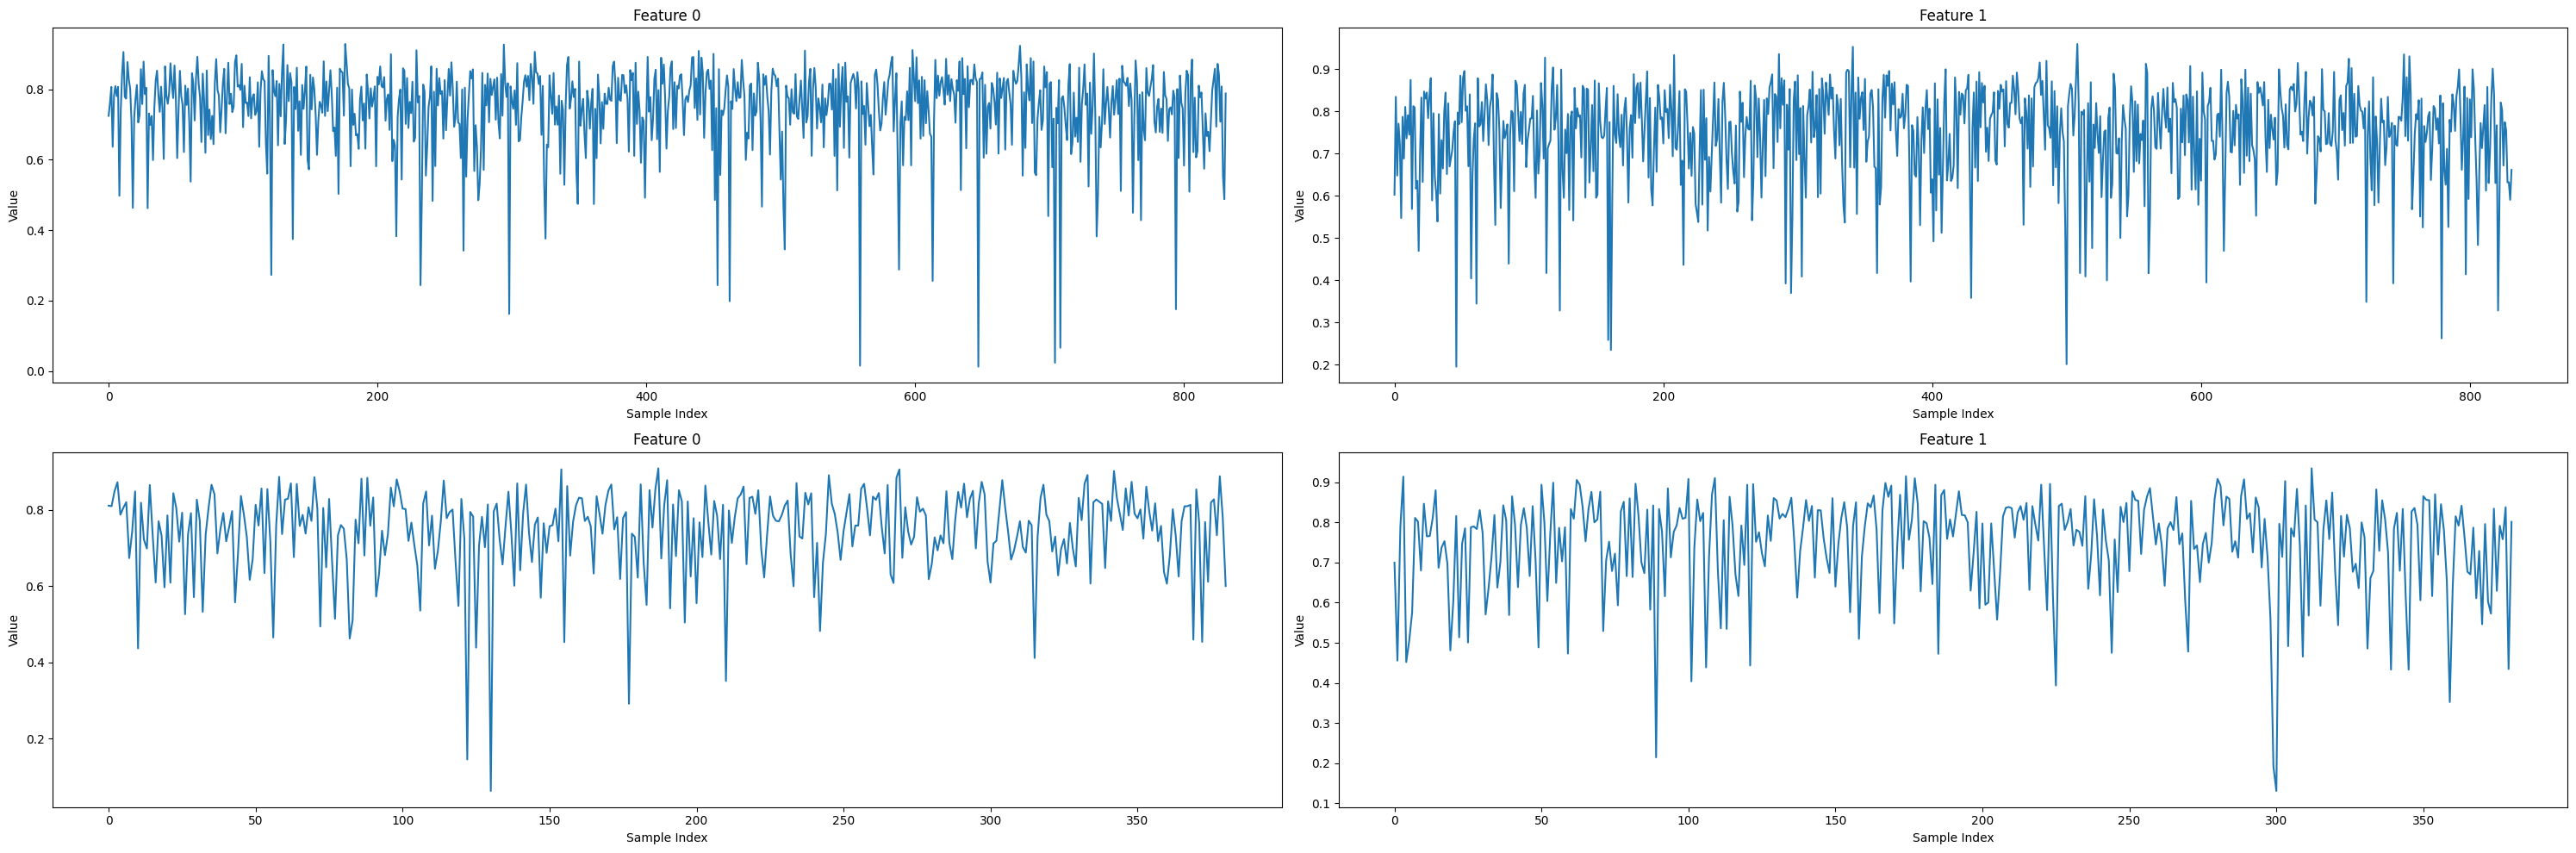

In [242]:
# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(30, 10))  # 4 rows x 3 columns = 12 subplots
axes = axes.flatten()  # So we can index them easily in a loop

# Plot each of the first 12 features
for i in range(2):
    axes[i].plot(vector_dataset[:832, i])
    axes[i].set_title(f'Feature {i}')
    axes[i].set_xlabel('Sample Index')
    axes[i].set_ylabel('Value')

for i in range(2, 4):
    axes[i].plot(vector_dataset[832:, i-2])
    axes[i].set_title(f'Feature {i-2}')
    axes[i].set_xlabel('Sample Index')
    axes[i].set_ylabel('Value')

# Adjust layout
plt.tight_layout()
plt.show()

IndexError: index 2 is out of bounds for axis 1 with size 2

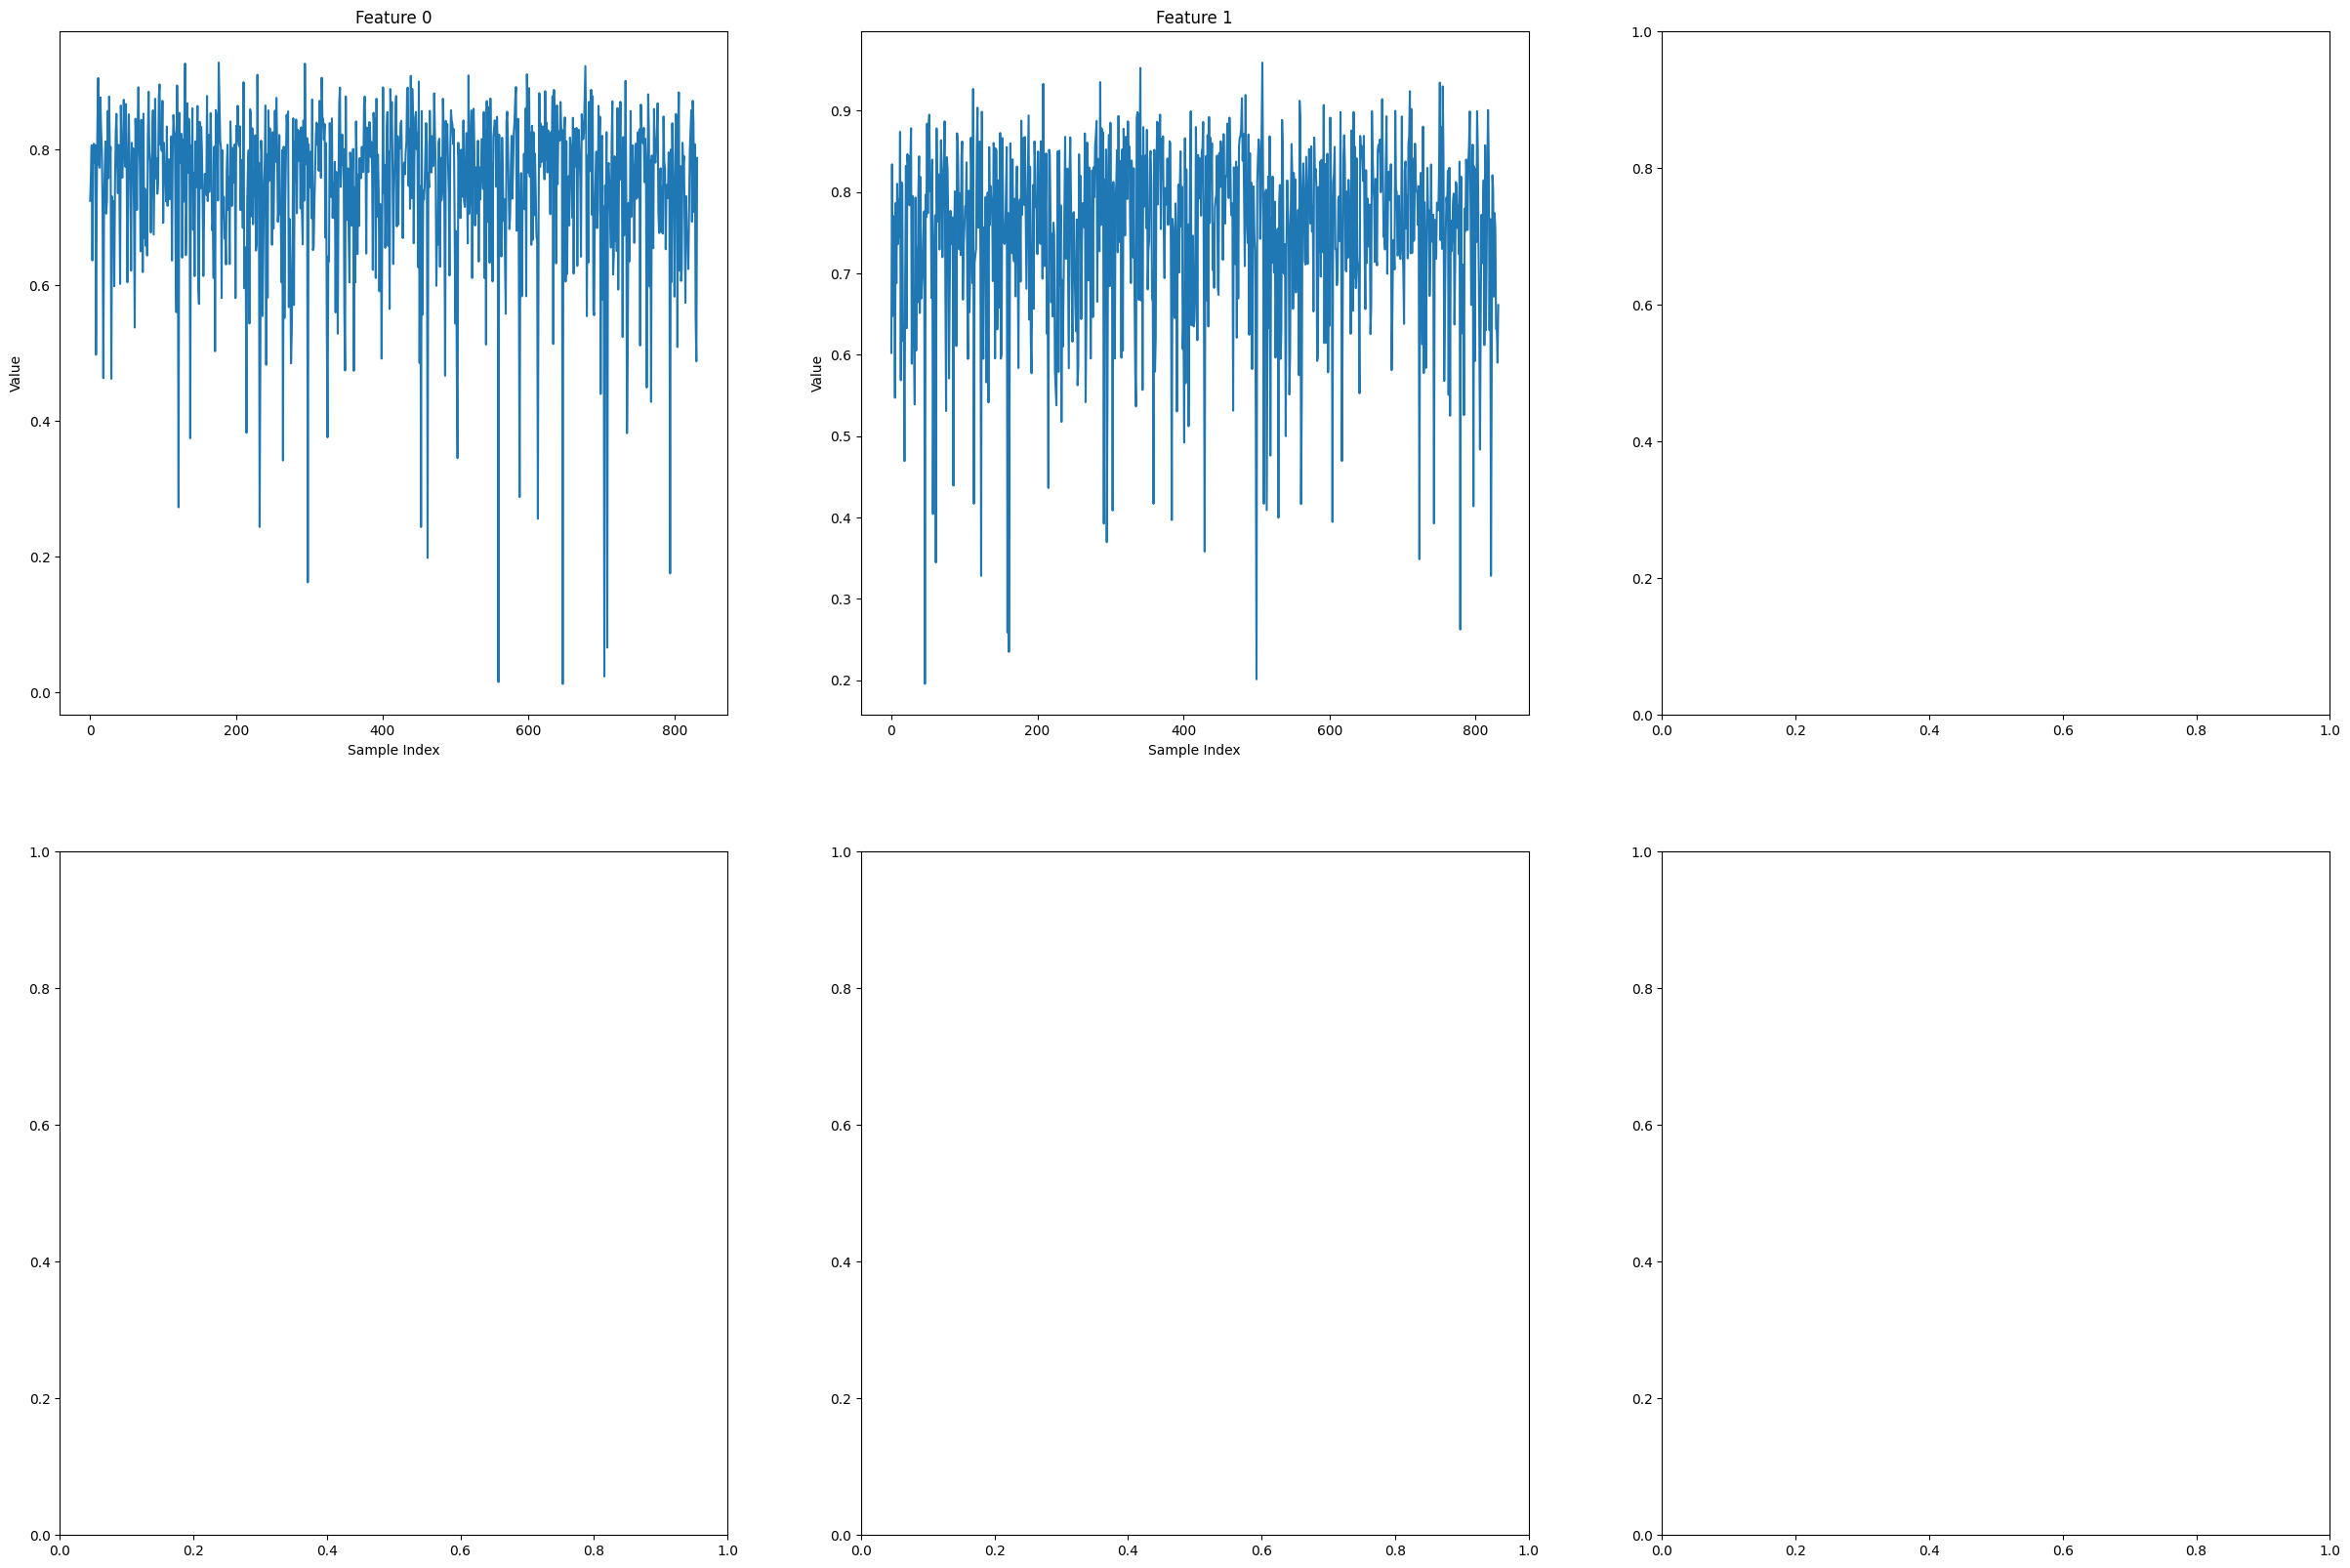

In [241]:
# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(30, 20))  # 4 rows x 3 columns = 12 subplots
axes = axes.flatten()  # So we can index them easily in a loop

# Plot each of the first 12 features
for i in range(3):
    axes[i].plot(vector_dataset[:832, i])
    axes[i].set_title(f'Feature {i}')
    axes[i].set_xlabel('Sample Index')
    axes[i].set_ylabel('Value')

for i in range(3, 6):
    axes[i].plot(vector_dataset[832:, i-3])
    axes[i].set_title(f'Feature {i-3}')
    axes[i].set_xlabel('Sample Index')
    axes[i].set_ylabel('Value')

# Adjust layout
plt.tight_layout()
plt.show()

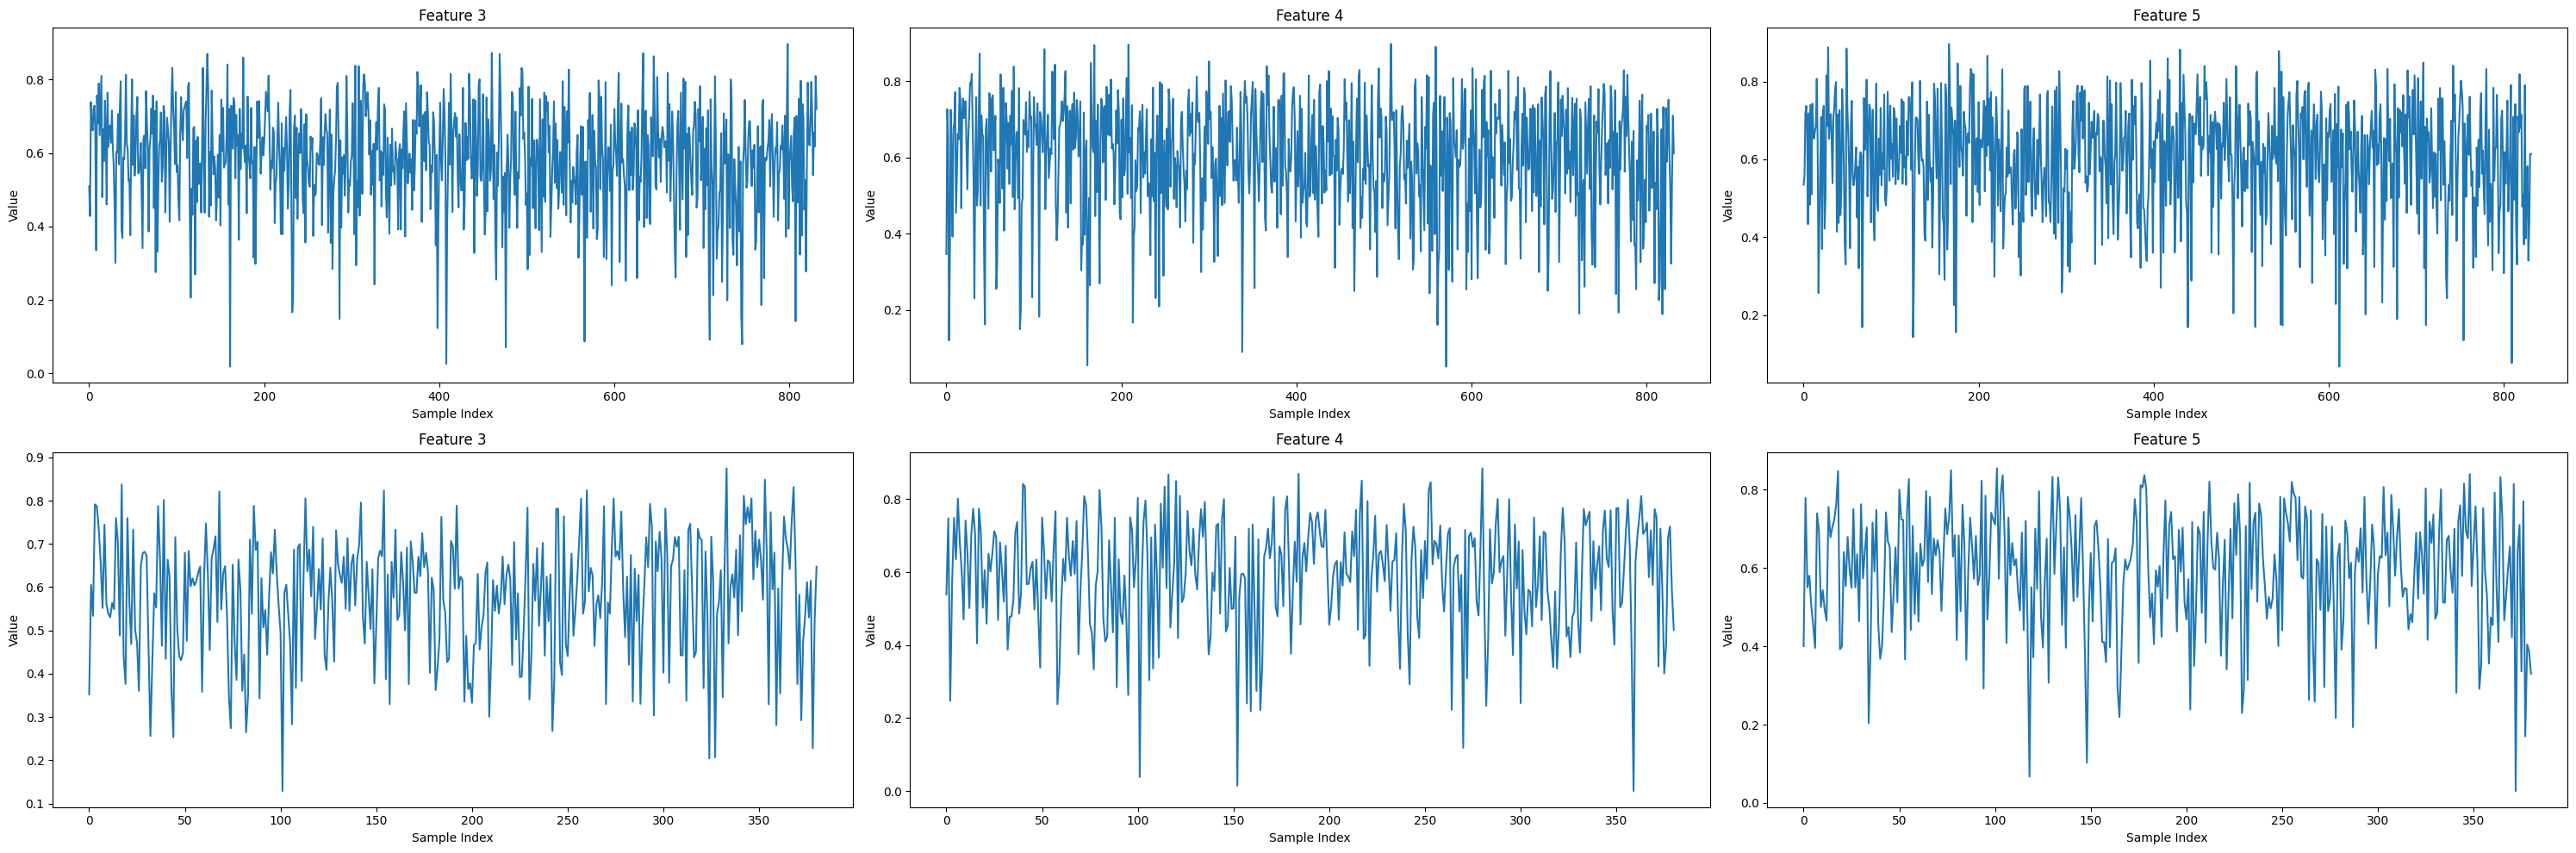

In [217]:
# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(30, 10))  # 4 rows x 3 columns = 12 subplots
axes = axes.flatten()  # So we can index them easily in a loop

# Plot each of the first 12 features
for i in range(3, 6):
    axes[i-3].plot(vector_dataset[:832, i])
    axes[i-3].set_title(f'Feature {i}')
    axes[i-3].set_xlabel('Sample Index')
    axes[i-3].set_ylabel('Value')

for i in range(6, 9):
    axes[i-3].plot(vector_dataset[832:, i-3])
    axes[i-3].set_title(f'Feature {i-3}')
    axes[i-3].set_xlabel('Sample Index')
    axes[i-3].set_ylabel('Value')

# Adjust layout
plt.tight_layout()
plt.show()

Modelling

In [260]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [261]:
# 1. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    vector_dataset, labels, test_size=0.2, random_state=42, stratify=labels, shuffle=True
)

In [268]:
from sklearn.ensemble import RandomForestClassifier

# 3. Model Training (Random Forest)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Prediction on test set
y_pred = model.predict(X_test)

# 5. Evaluation on test set
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("\n--- Test Set Performance (Random Forest) ---")
print(f"Accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(report)

# 6. Evaluation on training set
y_train_pred = model.predict(X_train)

train_accuracy = accuracy_score(y_train, y_train_pred)
train_conf_matrix = confusion_matrix(y_train, y_train_pred)
train_report = classification_report(y_train, y_train_pred)

print("\n--- Training Set Performance (Random Forest) ---")
print(f"Training Accuracy: {train_accuracy:.4f}")
print("Training Confusion Matrix:")
print(train_conf_matrix)
print("Training Classification Report:")
print(train_report)



--- Test Set Performance (Random Forest) ---
Accuracy: 0.6790
Confusion Matrix:
[[  0  77]
 [  1 165]]
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        77
           1       0.68      0.99      0.81       166

    accuracy                           0.68       243
   macro avg       0.34      0.50      0.40       243
weighted avg       0.47      0.68      0.55       243


--- Training Set Performance (Random Forest) ---
Training Accuracy: 1.0000
Training Confusion Matrix:
[[305   0]
 [  0 665]]
Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       305
           1       1.00      1.00      1.00       665

    accuracy                           1.00       970
   macro avg       1.00      1.00      1.00       970
weighted avg       1.00      1.00      1.00       970

